In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

os.unsetenv('PROJ_LIB')

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams['font.family']         = 'DejaVu Sans'

path_to_era5      = '/home/abhis/india_power/data/era5/'
path_to_data      = '/home/abhis/india_power/gridpath_india_viz/data/'
path_to_processed = '/home/abhis/india_power/gridpath_india_viz/processed_data/'

path_to_images     = '/home/gterren/india_power/gridpath_india_viz/images/'
path_to_input      = '/home/gterren/india_power/input_data/'
path_to_scens      = '/home/gterren/india_power/scenarios/cost/'
path_to_zones      = '/home/gterren/india_power/data/vre-climate-data/selected-zones/'
path_to_mapre      = '/home/gterren/india_power/data/mapre/'
path_to_local_data = '/home/gterren/india_power/gridpath_india_viz/data/'

# Loading system load timepoints data

In [42]:
scenario = 'ra_new_credits_12prm_noccap'

# Load scenario csv file
system_load_ = pd.read_csv(path_to_processed + f'system_load-{scenario}.csv')

# Drop Bhutan from dataset
system_load_ = system_load_.loc[~(system_load_['load_zone'] == 'Bhutan')].reset_index(drop = True)

# Step 1: convert to string (so we preserve leading zeros if any) then to datetime
system_load_['datetime'] = pd.to_datetime(
    (system_load_['timepoint'].astype(int) - 1).astype(str),
    format='%Y%m%d%H'    # %Y=4-digit year, %m=month, %d=day, %H=hour (24-h)
)

# Step 2: extract components
system_load_['year']        = system_load_['datetime'].dt.year
system_load_['month']       = system_load_['datetime'].dt.month
system_load_['day']         = system_load_['datetime'].dt.day
system_load_['hour']        = system_load_['datetime'].dt.hour
system_load_['day_of_year'] = system_load_['datetime'].dt.dayofyear
print(system_load_.shape)

# Rename iterations
system_load_.drop(columns = ['H', 'A'], inplace = True)
print(system_load_.columns)

(5361120, 15)
Index(['timepoint', 'load_zone', 'static_load', 'net_imports',
       'overgeneration', 'unserved_energy', 'W', 'datetime', 'year', 'month',
       'day', 'hour', 'day_of_year'],
      dtype='object')


In [48]:
system_load_p_ = system_load_.copy()
system_load_p_['normalized_unserved_energy'] = 0
for load_zone in system_load_p_['load_zone'].unique():
    print(load_zone)
    for iteration in system_load_p_['W'].unique():
        idx_ = (system_load_p_['load_zone'] == load_zone) & (system_load_p_['W'] == iteration)
        system_load_p_.loc[idx_, 'normalized_unserved_energy'] = 100.*(system_load_p_.loc[idx_, 'unserved_energy']/system_load_p_.loc[idx_, 'static_load'].max())

system_load_p_ = system_load_p_.fillna(0.)
print(system_load_p_)

Andhra_Pradesh


/tmp/ipykernel_2795415/1704589296.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  system_load_p_.loc[idx_, 'normalized_unserved_energy'] = 100.*(system_load_p_.loc[idx_, 'unserved_energy']/system_load_p_.loc[idx_, 'static_load'].max())


Arunachal_Pradesh
Assam
Bihar
Chandigarh
Chhattisgarh
Dadra_Nagar_Haveli
Daman_Diu
Delhi
Goa
Gujarat
Haryana
Himachal_Pradesh
Jammu_Kashmir
Jharkhand
Karnataka
Kerala
Madhya_Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
Odisha
Puducherry
Punjab
Rajasthan
Sikkim
Tamil_Nadu
Telangana
Tripura
Uttar_Pradesh
Uttarakhand
West_Bengal
          timepoint          load_zone   static_load   net_imports  \
0        2040040101     Andhra_Pradesh  18479.474483  -5352.372034   
1        2040040101  Arunachal_Pradesh    329.816680    261.713331   
2        2040040101              Assam   4089.792284   2729.990137   
3        2040040101              Bihar   9839.340580   6541.317509   
4        2040040101         Chandigarh    261.737982    261.737982   
...             ...                ...           ...           ...   
5361115  2041033124          Telangana  15324.778762   8484.907689   
5361116  2041033124            Tripura    235.199579   -822.900705   
5361117  2041033124      Uttar_P

(758, 14)


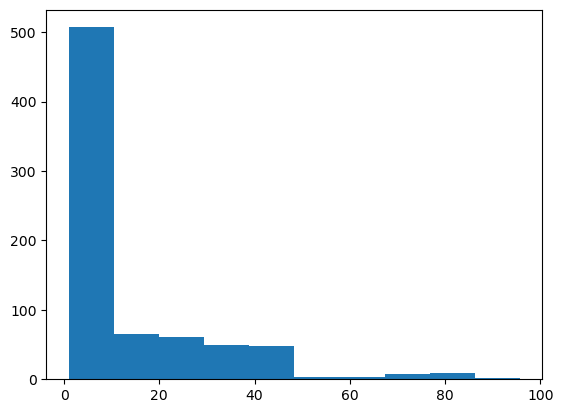

(1055, 14) 1153773.3685510394


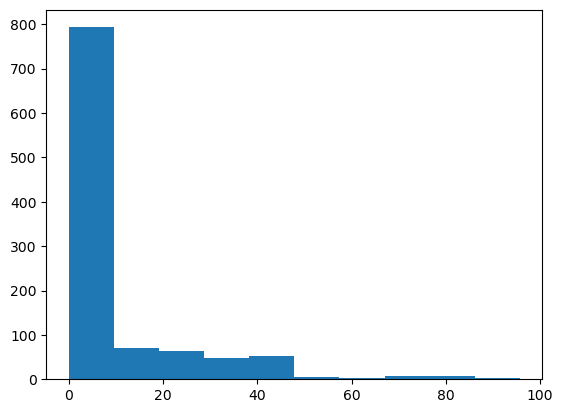

(208, 14) 1051546.074932241 1012.4233513483364


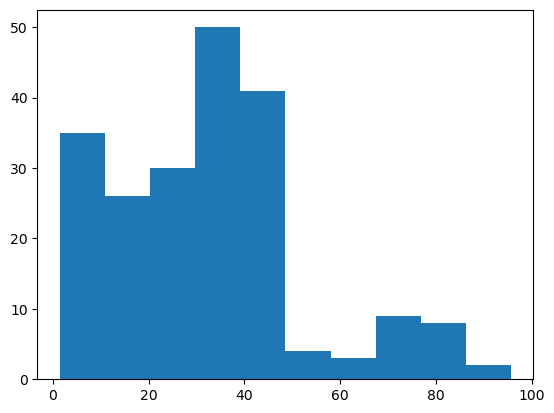

In [ ]:
idx_ = system_load_p_['normalized_unserved_energy'] > 1.
print(system_load_p_.loc[idx_].shape)

plt.figure()
plt.hist(system_load_p_.loc[idx_, 'normalized_unserved_energy'])
plt.show()

idx_ = system_load_p_['unserved_energy'] > 0.
print(system_load_p_.loc[idx_].shape, system_load_p_.loc[idx_, 'unserved_energy'].sum())

plt.figure()
plt.hist(system_load_p_.loc[idx_, 'normalized_unserved_energy'])
plt.show()

idx_ = system_load_p_['unserved_energy'] > 1000.
print(system_load_p_.loc[idx_].shape, system_load_p_.loc[idx_, 'unserved_energy'].sum(), system_load_p_.loc[idx_, 'normalized_unserved_energy'].min())

plt.figure()
plt.hist(system_load_p_.loc[idx_, 'normalized_unserved_energy'])
plt.show()

# Loading ERA5 weather tiempoints data

In [3]:
# Load scenario csv files:
# India_2000-2020_era5_temp.nc
df_t2m_ = pd.read_csv(path_to_local_data + 'avg_t2m.csv')
print(df_t2m_.shape)

# India_2000-2020_era5_cloud.nc
df_tcc_ = pd.read_csv(path_to_local_data + 'avg_tcc.csv')
print(df_tcc_.shape)

# India_2000-2020_era5_precipitation.nc
df_tp_ = pd.read_csv(path_to_local_data + 'avg_tp.csv')
print(df_tp_.shape)

# India_2000-2020_era5_wind10m.nc
df_wnd10m_ = pd.read_csv(path_to_local_data + 'avg_wnd10m.csv')
print(df_wnd10m_.shape)

# India_2000-2020_era5_wind100m.nc
df_wnd100m_ = pd.read_csv(path_to_local_data + 'avg_wnd100m.csv')
print(df_wnd100m_.shape)

# India_2000-2020_era5_ghi.nc
df_ghi_ = pd.read_csv(path_to_local_data + 'avg_ghi.csv')
print(df_ghi_.shape)

# India_2000-2020_era5_clear_sky.nc
df_cs_ = pd.read_csv(path_to_local_data + 'avg_cs.csv')
print(df_cs_.shape)

# Merge independent dataframes to form a single dataframe with all weather data
weather_ = df_t2m_.merge(df_tcc_, on = ['datetime', 'year', 'month', 'FY', 'iteration', 'load_zone'])
weather_ = weather_.merge(df_tp_, on = ['datetime', 'year', 'month', 'FY', 'iteration', 'load_zone'])
weather_ = weather_.merge(df_wnd10m_, on = ['datetime', 'year', 'month', 'FY', 'iteration', 'load_zone'])
weather_ = weather_.merge(df_wnd100m_, on = ['datetime', 'year', 'month', 'FY', 'iteration', 'load_zone'])
weather_ = weather_.merge(df_ghi_, on = ['datetime', 'year', 'month', 'FY', 'iteration', 'load_zone'])
weather_ = weather_.merge(df_cs_, on = ['datetime', 'year', 'month', 'FY', 'iteration', 'load_zone'])
del df_t2m_, df_tcc_, df_tp_, df_wnd10m_, df_wnd100m_, df_ghi_, df_cs_

# Add human calendar column
weather_['day']         = pd.to_datetime(weather_['datetime']).dt.day
weather_['hour']        = pd.to_datetime(weather_['datetime']).dt.hour
weather_['day_of_year'] = pd.to_datetime(weather_['datetime']).dt.dayofyear 

# Drop Bhutan from dataset
weather_ = weather_.loc[~(weather_['load_zone'] == 'Bhutan')].reset_index(drop = True)

# Rename interation to match system load timepoints nomenclature
weather_.rename(columns = {'iteration': 'W'}, inplace = True)
print(weather_)

(4905600, 10)
(4905600, 10)
(4905600, 10)
(4905600, 10)
(4905600, 10)
(4905600, 10)
(4905600, 10)
                    datetime  year  month    FY   W        t2m      load_zone  \
0        2000-01-01 00:00:00  2000      1  2000   1  11.112665          India   
1        2000-01-01 01:00:00  2000      1  2000   1  11.112665          India   
2        2000-01-01 02:00:00  2000      1  2000   1  11.112665          India   
3        2000-01-01 03:00:00  2000      1  2000   1  11.112665          India   
4        2000-01-01 04:00:00  2000      1  2000   1  11.112665          India   
...                      ...   ...    ...   ...  ..        ...            ...   
4905595  2017-12-31 19:00:00  2017     12  2018  17  -1.563469  Jammu_Kashmir   
4905596  2017-12-31 20:00:00  2017     12  2018  17  -3.487147  Jammu_Kashmir   
4905597  2017-12-31 21:00:00  2017     12  2018  17  -3.881330  Jammu_Kashmir   
4905598  2017-12-31 22:00:00  2017     12  2018  17  -4.478760  Jammu_Kashmir   
4905599  20

# Extreme weather detection

In [41]:
def _moving_window(x, window_shape):

    # Ensure the window size is odd for symmetric padding
    half = window_shape // 2

    # Pad the array on both ends
    x_padded = np.pad(x, 
                      pad_width = half, 
                      mode = 'edge')
    
    # Create sliding windows
    return np.lib.stride_tricks.sliding_window_view(x_padded, window_shape = window_shape)[:-1]

# The India Meteorological Department (IMD) defines standard categories for daily (24-hour) rainfall intensity.
# These categories are based on the total rainfall measured over 24 hours (typically measured from 08:30 AM
# IST on one day to 08:30 AM the next day). The classifications are as follows:
def _intense_rainfall(x_):

    z_ = np.zeros(x_.shape)

    # 24-hour rainfall total in millimetres
    Y_ = _moving_window(x_, window_shape = 24)

    # Compute the sum over the window dimension
    y_ = Y_.sum(axis = 1)

    # No rain, R24 = 0
    # Very light, 0 < R24 ≤ 2.4
    #z_[y_ > 0] += 1

    # Light, 2.5 ≤ R24 ≤ 15.5
    z_[y_ > 2.4] += 1

    # Moderate, 15.6 ≤ R24 ≤ 64.4
    z_[y_ > 15.4] += 1

    # Heavy, 64.5 ≤ R24 ≤ 115.5
    y_[y_ > 64.4] += 1

    # Very heavy, 115.6 ≤ R24 ≤ 204.4
    z_[y_ > 115.4] += 1

    # Extremely heavy, R24 ≥ 204.5
    z_[y_ > 204.4] += 1

    return z_

# It’s a station-wise climatological normal of the daily maximum temperature for that time of year, 
# built from a 30-year baseline.
# IMD states that for heat-wave monitoring it prepares the normal maximum temperature 
# from the 1991–2020 period for each station and day.
# In real-time operations, IMD compares the day’s temperature to the station’s pentad normal (a 5-day
# climatological average around that calendar date) to compute the “departure from normal.”
def _heatwave(x_):

    z_ = np.zeros(x_.shape)

    # Daily normal (1991–2020) for that station & calendar day
    X_ = x_.reshape(x_.shape[0]//24, 24)

    Tnorm = np.mean(np.max(X_, axis = 1), axis = 0)

    #  Pentad normal (5-day running mean centered on the date)
    Y_ = _moving_window(x_, window_shape = 24*5)

    # Compute the average over the window dimension
    Tmean_ = Y_.mean(axis = 1)

    #  Departure-based minimum temperatures for HW
    z_[Tmean_ > (Tnorm + 4.5)] += 1

    # and severe HW
    z_[Tmean_ > (Tnorm + 6.5)] += 1

    return z_

# The India Meteorological Department (IMD) – as WMO’s Regional Specialized Meteorological Centre for
# the North Indian Ocean – classifies tropical cyclonic disturbances based on their maximum sustained surface
# wind speeds. The categories and wind-speed thresholds are:
def _hurricane_wind(x_):

    y_ = np.zeros(x_.shape)

    # Depression: 17–27 knots (31–49 km/h)
    y_[x_ >= 31] += 1

    # Deep Depression: 28–33 knots (50–61 km/h)
    y_[x_ >= 50] += 1

    # Cyclonic Storm: 34–47 knots (62–88km/h)
    y_[x_ >= 62] += 1

    # Severe Cyclonic Storm: 48–63 knots (89–117 km/h)
    y_[x_ >= 89] += 1

    # Very Severe Cyclonic Storm (VSCS): 64–89 knots (118–166 km/h)
    y_[x_ >= 118] += 1

    # Extremely Severe Cyclonic Storm (ESCS): 90–119 knots (167–221 km/h)
    y_[x_ >= 167] += 1

    # Super Cyclonic Storm: ≥ 120 knots (≥222 km/h)
    y_[x_ >= 222] += 1

    return y_

def _anticyclonic_gloom(x_):
        
    z_ = np.zeros(x_.shape)

    # 24-hour rainfall total in millimetres
    Y_ = _moving_window(x_, window_shape = 24*2)

    # Compute the sum over the window dimension
    y_ = Y_.min(axis = 1)

    # Clear or Sunny: 0% cloud cover
    # Mostly Sunny or Mostly Clear: 1/8 to 2/8 cloud cover (12.5%–25%)
    z_[y_ >= 12.5] += 1

    # Partly Cloudy or Partly Sunny: 3/8 to 5/8 cloud cover (37.5%–62.5%)
    z_[y_ >= 37.5] += 1

    # Mostly Cloudy: 6/8 to 7/8 cloud cover (75%–87.5%)
    z_[y_ >= 75.] += 1

    # Cloudy: 8/8 cloud cover (100%)
    z_[y_ > 87.5] += 1

    return z_

# Drop all national-level entries
state_weather_ = weather_.loc[~(weather_['load_zone'] == 'India')].reset_index(drop = True).copy()
print(state_weather_.shape)

extreme_state_weather_ = []
for load_zone in state_weather_['load_zone'].unique():
    print(load_zone)
    for interation in state_weather_['W'].unique():
        #print(interation)

        # Filter out load_zones and interations from original dataframe
        df_ = state_weather_.loc[
            (state_weather_['load_zone'] == load_zone) & (state_weather_['W'] == interation)
            ].reset_index(drop = True).copy()
        
        # Sort dataframe by year, month, day, and hour
        df_ = df_.sort_values(by        = ['year', 'month', 'day', 'hour'], 
                              ascending = [True, True, True, True]).fillna(0.)
        
        # Extreme weather indicators
        df_['extreme_wind_wnd10m_pow']   = _hurricane_wind(df_['wnd10m_pow'].to_numpy())
        df_['extreme_wind_wnd10m']       = _hurricane_wind(df_['wnd10m'].to_numpy())
        df_['extreme_wind_wnd100m_wind'] = _hurricane_wind(df_['wnd100m_wind'].to_numpy())
        df_['extreme_gloom_tp_solar']    = _anticyclonic_gloom(df_['tcc_solar'].to_numpy())
        df_['extreme_heat_t2m_pow']      = _heatwave(df_['t2m_pow'].to_numpy())
        df_['extreme_heat_t2m']          = _heatwave(df_['t2m'].to_numpy())
        df_['extreme_rainfall_tp_pow']   = _intense_rainfall(df_['tp_pow'].to_numpy())
        df_['extreme_rainfall_tp']       = _intense_rainfall(df_['tp'].to_numpy())

        # Drop unnecessary columns
        df_ = df_[['datetime',
                   'FY',
                   'W', 
                   'year',
                   'day_of_year',
                   'month',
                   'day',
                   'hour',
                   'load_zone',
                   'extreme_wind_wnd10m_pow',
                   'extreme_wind_wnd10m',
                   'extreme_wind_wnd100m_wind',
                   'extreme_heat_t2m_pow',
                   'extreme_heat_t2m',
                   'extreme_rainfall_tp_pow',
                   'extreme_rainfall_tp']]
        
        extreme_state_weather_.append(df_)

extreme_state_weather_ = pd.concat(extreme_state_weather_, axis = 0)
print(extreme_state_weather_.shape)

extreme_state_weather_['indicator_wnd10m_pow']      = (extreme_state_weather_['extreme_wind_wnd10m_pow'] != 0).astype(int)
extreme_state_weather_['indicator_wnd10m']          = (extreme_state_weather_['extreme_wind_wnd10m'] != 0).astype(int)
extreme_state_weather_['indicator_wnd100m_wind']    = (extreme_state_weather_['extreme_wind_wnd100m_wind'] != 0).astype(int)
extreme_state_weather_['indicator_t2m_pow']         = (extreme_state_weather_['extreme_heat_t2m_pow'] != 0).astype(int)
extreme_state_weather_['indicator_t2m']             = (extreme_state_weather_['extreme_heat_t2m'] != 0).astype(int)
extreme_state_weather_['indicator_rainfall_tp_pow'] = (extreme_state_weather_['extreme_rainfall_tp_pow'] != 0).astype(int)
extreme_state_weather_['indicator_rainfall_tp']     = (extreme_state_weather_['extreme_rainfall_tp'] != 0).astype(int)

print(extreme_state_weather_['indicator_wnd10m_pow'].sum())
print(extreme_state_weather_['indicator_wnd10m'].sum())
print(extreme_state_weather_['indicator_wnd100m_wind'].sum())
print(extreme_state_weather_['indicator_t2m_pow'].sum())
print(extreme_state_weather_['indicator_t2m'].sum())
print(extreme_state_weather_['indicator_rainfall_tp_pow'].sum())
print(extreme_state_weather_['indicator_rainfall_tp'].sum())

(4765440, 37)
Arunachal_Pradesh
Assam
Bihar
Chandigarh
Chhattisgarh
Dadra_Nagar_Haveli
Daman_Diu
Goa
Gujarat
Haryana
Himachal_Pradesh
Jharkhand
Karnataka
Kerala
Madhya_Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
Delhi
Puducherry
Punjab
Rajasthan
Sikkim
Tamil_Nadu
Telangana
Tripura
Uttar_Pradesh
Uttarakhand
West_Bengal
Odisha
Andhra_Pradesh
Jammu_Kashmir
(4765440, 16)
334
836
88819
28174
54113
1702485
1771923


In [ ]:
extreme_national_weather_ = extreme_state_weather_.groupby(['datetime',
                                                            'FY',
                                                            'W',
                                                            'year',
                                                            'day_of_year',
                                                            'month',
                                                            'day',
                                                            'hour']).agg({'extreme_wind_wnd10m_pow': 'max',
                                                                          'extreme_wind_wnd10m': 'max',
                                                                          'extreme_wind_wnd100m_wind': 'max', 
                                                                          'extreme_heat_t2m_pow': 'max',
                                                                          'extreme_heat_t2m': 'max',
                                                                          'extreme_rainfall_tp_pow': 'max',
                                                                          'extreme_rainfall_tp': 'max',
                                                                          'indicator_wnd10m_pow': 'sum',
                                                                          'indicator_wnd10m': 'sum',
                                                                          'indicator_wnd100m_wind': 'sum',
                                                                          'indicator_t2m_pow': 'sum',
                                                                          'indicator_t2m': 'sum',
                                                                          'indicator_rainfall_tp_pow': 'sum',
                                                                          'indicator_rainfall_tp': 'sum'}).reset_index(drop = False)

print(extreme_national_weather_['indicator_wnd10m_pow'].sum())
print(extreme_national_weather_['indicator_wnd10m'].sum())
print(extreme_national_weather_['indicator_wnd100m_wind'].sum())
print(extreme_national_weather_['indicator_t2m_pow'].sum())
print(extreme_national_weather_['indicator_t2m'].sum())
print(extreme_national_weather_['indicator_rainfall_tp_pow'].sum())
print(extreme_national_weather_['indicator_rainfall_tp'].sum())

334
836
88819
28174
54113
1702485
1771923


: 

In [8]:
# Drop all state-level entries
national_weather_ = weather_.loc[weather_['load_zone'] == 'India'].reset_index(drop = True).copy()
print(national_weather_)
print(national_weather_['W'].unique())

                   datetime  year  month    FY   W        t2m load_zone  \
0       2000-01-01 00:00:00  2000      1  2000   1  11.112665     India   
1       2000-01-01 01:00:00  2000      1  2000   1  11.112665     India   
2       2000-01-01 02:00:00  2000      1  2000   1  11.112665     India   
3       2000-01-01 03:00:00  2000      1  2000   1  11.112665     India   
4       2000-01-01 04:00:00  2000      1  2000   1  11.112665     India   
...                     ...   ...    ...   ...  ..        ...       ...   
140155  2017-12-31 19:00:00  2017     12  2018  17  19.839211     India   
140156  2017-12-31 20:00:00  2017     12  2018  17  17.432426     India   
140157  2017-12-31 21:00:00  2017     12  2018  17  15.993833     India   
140158  2017-12-31 22:00:00  2017     12  2018  17  15.231049     India   
140159  2017-12-31 23:00:00  2017     12  2018  17  14.458833     India   

          t2m_pow  t2m_solar   t2m_wind  ...   ghi_pow  ghi_solar  ghi_wind  \
0       12.226272  1

In [ ]:
def _plot_heatmap_hourly(fig, ax_, df_, system_feature, 
                  cmap= '',
                  colorbar_title = '',
                  units = 1): 
    

    # N_iterations = df_['iteration'].nunique()
    N_hours       =24
    # print(N_iterations, N_hours, df_.shape)

    # df_['hourofyear'] = (df_['month'] - 1) * 24  + df_['interval']

    df_p_ = df_.pivot_table(index='year_day', columns='interval', values=system_feature).sort_index().to_numpy()/units
    print(df_p_.shape)


    month_days_     = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    months_         = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    cum_month_days_ = np.cumsum(month_days_)
    

    _cmap = sns.color_palette(cmap, as_cmap=True)
    _norm = mcolors.Normalize(vmin=df_p_.min(), vmax=df_p_.max())

    for i in range(12):
        ax_[i].imshow(df_p_[cum_month_days_[i]:cum_month_days_[i + 1], :].T, 
                      origin        = 'lower', 
                      aspect        = 'auto', 
                      cmap          = _cmap,
                      interpolation = 'None', norm=_norm)
        
        ax_[i].set_xticks([month_days_[i + 1]/2], [months_[i]], fontsize = 16)
        ax_[i].tick_params(axis = "x", length = 0)
        ax_[i].set_yticks([], [])
        ax_[i].xaxis.tick_top()

    # iterations_ = np.sort(df_['iteration'].unique())
    x_ = np.linspace(0, N_hours - 1, N_hours)
    ax_[0].set_yticks(x_ - 0.5, [f'{int(x)}:00' for x in x_], fontsize = 14)

    cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                        cax = ax_[5].inset_axes([-215, -2, 50., 1.], transform = ax_[-1].transData), 
                        orientation = 'horizontal')

    cbar.set_ticks([0, 1], labels = [f'{np.around(df_p_.min(),1)}', 
    f'{np.around(df_p_.max(),1)}'], size = 14)
    # ax_[0].set_ylabel("Hour", fontsize=16)
    # ax.set_ylabel("Iteration", fontsize=14)
    # ax.set_xlabel("")

    cbar.ax.tick_params(labelsize=14, length=3)
    #cbar.ax.set_title(colorbar_title, rotation = 0, size = 12)
    cbar.set_label(colorbar_title, rotation=0, labelpad=15, fontsize=16, loc='center')

fig_, ax_ = plt.subplots(figsize = (20, 5.5), 
                         nrows = 1,
                         ncols = 12)

system_factor = 'net_load_pct'

_plot_heatmap_hourly(fig_, ax_, df_national_project_hourly_avg, system_factor, 
              cmap ="Spectral_r",
              colorbar_title = 'Net Load Percentage (%)', 
              units=1)
# plt.savefig(path_to_images + f'/ra-{system_factor}_heatmap-national.png', 
#             bbox_inches = 'tight', 
#             dpi = 600)

# plt.savefig(path_to_images + f'/ra-{system_factor}_heatmap-national.pdf', 
#             bbox_inches = 'tight', 
#             dpi = 600)

plt.show()

In [ ]:
def _plot_heatmap(fig, ax_, df_, system_feature, 
                  cmap= '',
                  colorbar_title = '',
                  units = 1): 
    

    N_iterations = df_['iteration'].nunique()
    N_days       = 365
    print(N_iterations, N_days, df_.shape)

    df_p_ = df_.pivot_table(index='year_day', columns='iteration', values=system_feature).sort_index().to_numpy()/units
    print(df_p_.shape)


    month_days_     = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    months_         = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    cum_month_days_ = np.cumsum(month_days_)
    
    _cmap = sns.color_palette(cmap, as_cmap=True)
    _norm = mcolors.Normalize(vmin=df_p_.min(), vmax=df_p_.max())

    for i in range(12):
        ax_[i].imshow(df_p_[cum_month_days_[i]:cum_month_days_[i + 1], :].T, 
                      origin        = 'lower', 
                      aspect        = 'auto', 
                      cmap          = _cmap,
                      interpolation = 'None', norm=_norm)
        
        ax_[i].set_xticks([month_days_[i + 1]/2], [months_[i]], fontsize = 16)
        ax_[i].tick_params(axis = "x", length = 0)
        ax_[i].set_yticks([], [])
        ax_[i].xaxis.tick_top()

    iterations_ = np.sort(df_['iteration'].unique())
    ax_[0].set_yticks(np.linspace(0, N_iterations - 1, N_iterations), iterations_, fontsize = 14)

    cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                        cax = ax_[5].inset_axes([-215, -2, 50., 1.], transform = ax_[-1].transData), 
                        orientation = 'horizontal')

    cbar.set_ticks([0, 1], labels = [f'{np.around(df_p_.min(),1)}', 
    f'{np.around(df_p_.max(),1)}'], size = 14)
    ax_[0].set_ylabel("Iteration", fontsize=16)
    # ax.set_ylabel("Iteration", fontsize=14)
    # ax.set_xlabel("")

    cbar.ax.tick_params(labelsize=14, length=3)
    #cbar.ax.set_title(colorbar_title, rotation = 0, size = 12)
    cbar.set_label(colorbar_title, rotation=0, labelpad=15, fontsize=16, loc='center')

fig_, ax_ = plt.subplots(figsize = (20, 5.5), 
                         nrows = 1,
                         ncols = 12)

system_factor = 'tx_cap_factor_national'

_plot_heatmap(fig_, ax_, df_national_project_daily, system_factor, 
              cmap ="Spectral_r",
              colorbar_title = 'TX Capacity Factor (%)', 
              units=1e-2)

# plt.savefig(path_to_images + f'/ra-{system_factor}_heatmap-national.png', 
#             bbox_inches = 'tight', 
#             dpi = 600)

# plt.savefig(path_to_images + f'/ra-{system_factor}_heatmap-national.pdf', 
#             bbox_inches = 'tight', 
#             dpi = 600)

plt.show()

In [ ]:
def plot_system_factor_histgram(ax, df_, system_factor, xmin = 0, xmax =1, 
                                xlabel = '', ylabel = '', tau=0.0, units=1):

    df_filtered = df_[df_['unserved_energy'] > tau].copy()

    ue_     = df_filtered['unserved_energy'].values
    factor_ = df_filtered[system_factor].values
    ax.hist(df_[system_factor].values/units, bins=25, range = (xmin, xmax), cumulative=False, density=True,
            color='orange', edgecolor='w', lw = 0.25, alpha=0.75, zorder=4)
    
    (n, bins, patches) = ax.hist(factor_/units, range = (xmin, xmax), bins=25, cumulative=False, density=True,
            color='teal', edgecolor='w', lw = 0.25, alpha=0.75, zorder=5)
    

    ax.set_xlim(bins.min() - .025*bins.max(), bins.max() + .025*bins.max())

    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    # ax.set_xlim(xmin - 1, xmax + 1)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.legend(['All Hours', 'Unserved Energy Hours'], fontsize=12, frameon=False, handlelength=1, handleheight=1, handletextpad=0.5)

    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.grid(axis = 'y', zorder = 0)

fig, ax = plt.subplots(figsize=(5, 5))

system_factor='vre_cap_factor'
plot_system_factor_histgram(ax, df_national_project, system_factor=system_factor, 
                            xmin = 0, 
                            xmax = 60, 
                            tau=1., 
                            units = 1e-2,
                            ylabel = 'VRE Capacity Factor Distribution',
                            xlabel = 'VRE Capacity Factor (%)')


# plt.savefig(path_to_save_images + f'/national-level_{system_factor}_dist.png',
#             bbox_inches = 'tight',
#             dpi         = 600)

# plt.savefig(path_to_save_images + f'/national-level_{system_factor}_dist.pdf',
#             bbox_inches = 'tight',
#             dpi         = 600)

plt.show()

In [ ]:
def plot_system_factor_frequency(ax, df_, system_factor, xmin = 0, xmax =1.0, tau=0.0,units=1,xlabel = '', ylabel = ''):

    df_filtered = df_[df_['unserved_energy'] > tau].copy()

    ue_ = df_filtered['unserved_energy'].values
    factor_ = df_filtered[system_factor].values/units

    # Sort by factor for cumulative plots
    idx_ = np.argsort(factor_)
    ue_sorted = ue_[idx_]
    factor_sorted = factor_[idx_]

    # p90 = np.nanpercentile(factor_, 70)
    # ax.axvline(p90, color='red', linestyle='--', lw=1.5, label='90th Percentile')
    y_ = np.cumsum(ue_sorted)/1000.
    y_ = 100.*y_/y_.max() # convert to GWh

    ax.plot(factor_sorted, y_, lw=2.5, color='teal')

    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
   
    ax.tick_params(axis='both', labelsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0,)

    ax.grid(axis = 'y', zorder = 0)
    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left']].set_visible(False)
 
    plt.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))

system_factor='vre_cap_factor'

plot_system_factor_frequency(ax, df_national_project, system_factor=system_factor, 
                            xmin = 0, 
                            xmax = 60, 
                            tau = 1., 
                            units = 1e-2,
                            ylabel = 'Unserved Energy Fraction (%)',
                            xlabel = 'VRE Capacity Factor (%)')

# plt.savefig(path_to_save_images + f'/national-level_{system_factor}_dist.png',
#             bbox_inches = 'tight',
#             dpi         = 600)

# plt.savefig(path_to_save_images + f'/national-level_{system_factor}_dist.pdf',
#             bbox_inches = 'tight',
#             dpi         = 600)

plt.show()